# Credit Card Fraud Detection Using Autoencoder

## Deep learning

Итак, мы добрались и до глубокого обучения. Все указанные выше классические методы были довольно требовательны: нам приходилось усердно работать с данными и параметрами самих моделей, чтобы добиться результата. Есть ли альтернатива?

### Автокодировщик

<img src="https://i0.wp.com/sefiks.com/wp-content/uploads/2018/03/autoencoder.jpeg?w=638&ssl=1" width=800>

Как видно из рисунка, автокодировщик имеет ту же архитектуру, что и обычный MLP (многослойный перцептрон), за исключением требования, чтобы количество входных нейронов было равно количеству нейронов в выходном слое. Автокодировщик во время обучения выучивает внутренние представления данных так, чтобы по входу можно было реконструировать выход. Таким образом, это означает, что автокодировщик не может просто копировать ввод в вывод, он вынужден изучать наиболее важные признаки ввода и отбрасывать остальные.

Как мы можем использовать автокодировщик для обнаружения мошеннических транзакций? Автокодировщиком мы пытаемся оптимизировать модель (то есть параметры модели), чтобы минимизировать ошибку реконструкции.

Теперь предположим, что мы подаем цифру 5 и на выходе получаем восстановленную цифру 5 с минимальной ошибкой восстановления. Теперь попробуем скормить другую цифру, которая пытается имитировать 5, когда мы получим на выходах ее восстановленную версию, она будет с большой ошибкой реконструкции. Это логика использования автокодировщика для обнаружения мошенничества. На вход подаем вектор из признаков (30 признаков).

## Declare required dependencies

In [1]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Not Niche", "Niche"]

## Data ingestion

In [2]:
df = pd.read_csv("/content/sample_data/dota2HeroPick.csv")

# Adapt Dota dataset to the notebook format with binary target `Class`
df['Class'] = df['Niche Hero?'].astype(str).str.strip().str.lower().map({
    'yes': 1, 'y': 1, 'true': 1, '1': 1,
    'no': 0, 'n': 0, 'false': 0, '0': 0
})

df['Class'] = df['Class'].fillna(0).astype(int)
df = df.drop(columns=['Niche Hero?'])
df = pd.get_dummies(df, drop_first=True)

# Keep compatibility with existing exploratory cells
if 'Amount' not in df.columns:
    df['Amount'] = 0.0
if 'Time' not in df.columns:
    df['Time'] = np.arange(len(df), dtype=float)

## Data exploration

In [3]:
df.head(5)

,Unnamed: 0,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate,Class,Name_Alchemist,Name_Ancient Apparition,Name_Anti-Mage,...,"Roles_Support, Nuker, Durable, Disabler, Pusher","Roles_Support, Nuker, Escape, Disabler","Roles_Support, Nuker, Initiator, Escape, Disabler","Roles_Support, Nuker, Initiator, Pusher, Disabler","Roles_Support, Nuker, Pusher, Disabler","Roles_Support, Pusher","Roles_Support, Pusher, Disabler, Nuker, Initiator","Roles_Support, Pusher, Durable, Disabler",Amount,Time
0,0,150,8,24,61,33.33,0,False,False,False,...,False,False,False,False,False,False,False,False,0.0,0.0
1,1,150,23,55,22,41.82,0,True,False,False,...,False,False,False,False,False,False,False,False,0.0,1.0
2,2,675,40,77,73,51.95,0,False,True,False,...,False,False,False,False,False,False,False,False,0.0,2.0
3,3,150,40,66,78,60.61,0,False,False,True,...,False,False,False,False,False,False,False,False,0.0,3.0
4,4,625,5,14,31,35.71,0,False,False,False,...,False,False,False,False,False,False,False,False,0.0,4.0


In [4]:
print(df.shape)
print(df.describe())

(124, 237)
       Unnamed: 0  Attack Range  Total Pro wins  Times Picked  Times Banned  \
count  124.000000    124.000000      124.000000    124.000000    124.000000   
mean    61.500000    350.604839       91.975806    183.951613    255.112903   
std     35.939764    200.271759       73.328691    143.145492    241.567349   
min      0.000000    150.000000        4.000000      5.000000     18.000000   
25%     30.750000    150.000000       40.750000     82.500000     80.000000   
50%     61.500000    340.000000       79.000000    156.000000    185.500000   
75%     92.250000    550.000000      106.000000    215.250000    325.000000   
max    123.000000    700.000000      407.000000    801.000000   1049.000000   

         Win Rate       Class  Amount        Time  
count  124.000000  124.000000   124.0  124.000000  
mean    49.390726    0.161290     0.0   61.500000  
std      6.317535    0.369291     0.0   35.939764  
min     32.730000    0.000000     0.0    0.000000  
25%     46.217500

## Ести ли пропуски?

In [5]:
df.isnull().values.any()

np.False_

## Class distribution ( 0 - non fraudulent, 1 - fraudulent)

In [6]:
df['Class'].value_counts()

,count
Class,
0,104
1,20


/tmp/ipykernel_29994/8883725.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort = True)


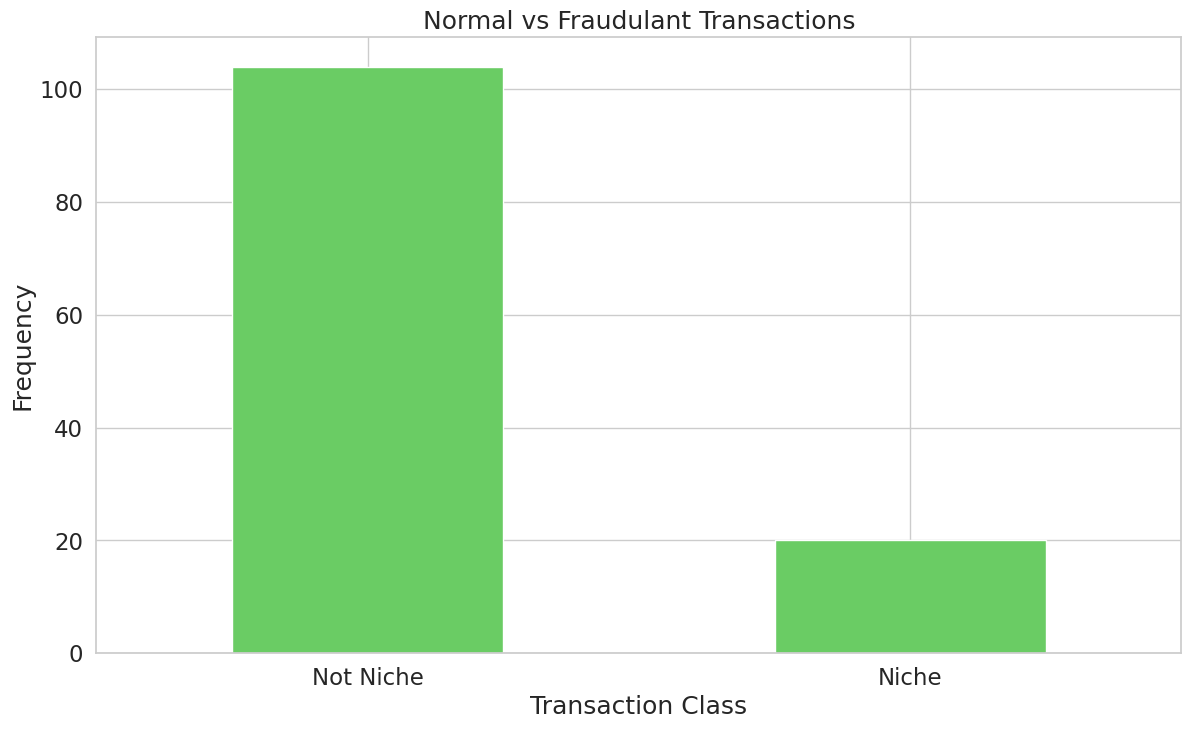

In [7]:
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0, color="g")
plt.title("Normal vs Fraudulant Transactions")
plt.xticks(range(2), LABELS)
plt.xlabel("Transaction Class")
plt.ylabel("Frequency");

Наш набор данных очень сильно несбалансирован в пользу отрицательного (0, то есть нормального) класса. Это требует дальнейшего изучения данных

In [8]:
fraudsDF = df[df.Class == 1]
normalDF = df[df.Class == 0]

In [9]:
fraudsDF.shape

(20, 237)

In [10]:
normalDF.shape

(104, 237)

Давайте теперь посмотрим на сумму денег, задействованную в двух классах.

In [11]:
fraudsDF.Amount.describe()

,Amount
count,20.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [12]:
normalDF.Amount.describe()

,Amount
count,104.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


Graphically speaking ...`

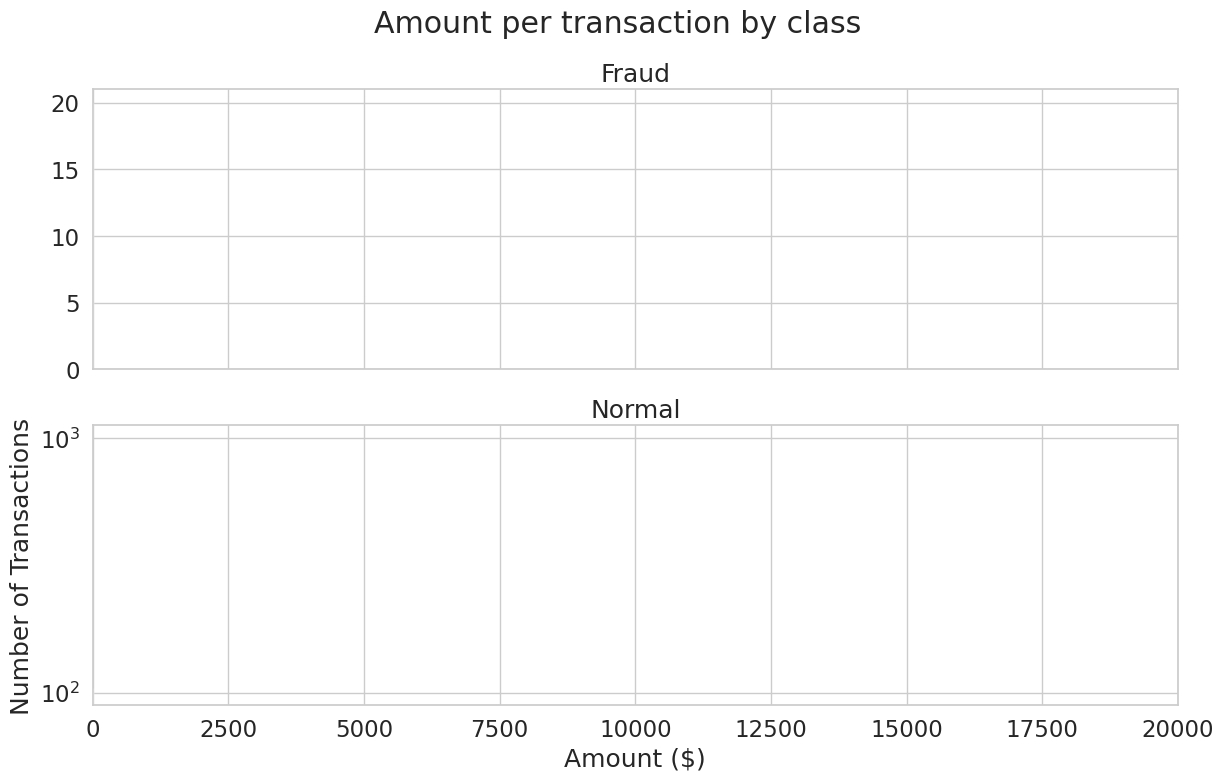

In [13]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')

bins = 50

ax1.hist(fraudsDF.Amount, bins = bins)
ax1.set_title('Fraud')

ax2.hist(normalDF.Amount, bins = bins)
ax2.set_title('Normal')

plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

Влияет ли время транзакции на мошеннические транзакции?

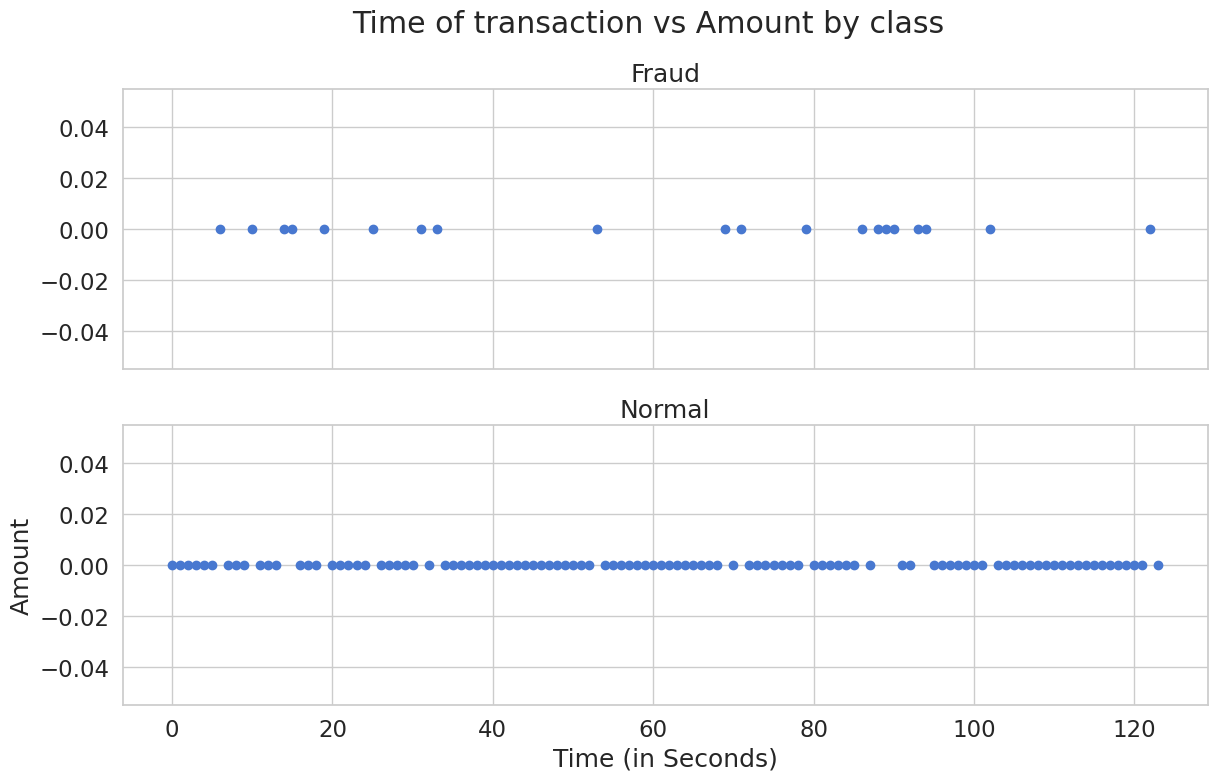

In [14]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')

ax1.scatter(fraudsDF.Time, fraudsDF.Amount)
ax1.set_title('Fraud')

ax2.scatter(normalDF.Time, normalDF.Amount)
ax2.set_title('Normal')

plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

Таким образом, очевидно, что время транзакции не имеет никакого отношения к мошеннической деятельности.

## Preprocessing

Поскольку, как показано выше, время транзакции не влияет на мошенническую деятельность, эта функция не будет способствовать обучению модели. Следовательно, мы можем отказаться от него.

In [15]:
transactionData = df.drop(['Time'], axis=1) if 'Time' in df.columns else df.copy()

Также давайте стандартизируем Amount.

In [16]:
if 'Amount' in transactionData.columns:
    transactionData['Amount'] = StandardScaler().fit_transform(transactionData['Amount'].values.reshape(-1, 1))

### Разделите набор данных на наборы обучающих и тестовых данных.

Мы разделили набор данных как обучение = 80% и тест = 20%. В обучающем наборе данных будут только обычные транзакции, а в тестовом наборе данных будут как обычные, так и мошеннические транзакции.

In [28]:
X_train, X_test = train_test_split(transactionData, test_size=0.2, random_state=RANDOM_SEED,
                                   stratify=transactionData['Class'])
X_train = X_train[X_train.Class == 0]
X_train = X_train.drop(['Class'], axis=1)
#print(type(X_train))
y_test = X_test['Class']
X_test = X_test.drop(['Class'], axis=1)

input_dim = X_train.shape[1]

X_train = X_train.values.astype(np.float64)
#print(type(X_train))
X_test = X_test.values.astype(np.float64)
y_test = y_test.values
print(y_test.size)


25


## Model
Мы построим автоэнкодер, состоящий из 4 полносвязных слоев с 14,7,7,29 нейронами. Первые 2 слоя действуют как кодировщик, а последние 2 слоя действуют как декодер. Обратите внимание, что последний слой имеет 29 узлов, соответствующих 29 функциям в элементе входных данных.

In [18]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 14),
            nn.Tanh(),
            nn.Linear(14, 7),
            nn.LeakyReLU(),
            )

        self.decoder = nn.Sequential(
           nn.Linear(7, 7),
           nn.Tanh(),
           nn.Linear(7, input_dim),
           nn.LeakyReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [19]:
model = Autoencoder().double()
#model = Autoencoder().double().cpu()

In [20]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

**minibatch_size** - размер мини-пакета - это количество записей (или векторов), которые мы одновременно передаем в наш алгоритм обучения. Отношение между тем, насколько быстро наш алгоритм может обучить модель, обычно имеет U-образную форму (размер пакета в зависимости от скорости обучения). Это означает, что первоначально по мере увеличения размера партии время обучения будет уменьшаться. В конце концов  мы увидим, что время обучения начинает увеличиваться, когда мы превышаем определенный размер пакета, который слишком велик.
По мере увеличения размера мини-пакета большее количество вычислений означает, что градиенты могут быть более плавными, но их вычисление требует больших затрат. В идеале каждая мини-партия, на которой проводится обучение, должна содержать пример каждого класса, чтобы уменьшить ошибку выборки при оценке градиента для всей обучающей выборки.


**learning_rate** - скорость оптимизации (обучения). Насколько маленькими шашами мы изменяем градиент.

In [21]:

train_loader = data_utils.DataLoader(X_train, batch_size=minibatch_size, shuffle=True)


In [22]:

#test = data_utils.TensorDataset(torch.from_numpy(X_test).double(),torch.from_numpy(y_test).double())
#test_loader = data_utils.DataLoader(test, batch_size=minibatch_size, shuffle=True)
test_loader = data_utils.DataLoader(X_test, batch_size=1, shuffle=False)

In [23]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
model.parameters(), lr=learning_rate, weight_decay=10e-05)


In [24]:
history = {}
history['train_loss'] = []
history['test_loss'] = []


In [30]:
train_data_tensor = torch.from_numpy(X_train).double()
train_dataset = data_utils.TensorDataset(train_data_tensor)
train_loader = data_utils.DataLoader(train_dataset, batch_size=minibatch_size, shuffle=True)

for epoch in range(num_epochs):
    h = np.array([])
    for data_tuple in train_loader:
        data = data_tuple[0] # Extract the actual data tensor from the tuple
        #print(type(data))
        #data = Variable(data).cpu()
        #print(type(data))
        # ===================forward=====================
        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # ===================log========================
    mean_loss = np.mean(h)
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch + 1, num_epochs, mean_loss))
    history['train_loss'].append(mean_loss)


torch.save(model.state_dict(), './credit_card_model.pth')

epoch [1/100], loss:1702.1346
epoch [2/100], loss:1714.7882
epoch [3/100], loss:1693.1138
epoch [4/100], loss:1702.9229
epoch [5/100], loss:1754.4161
epoch [6/100], loss:1652.5053
epoch [7/100], loss:1628.0495
epoch [8/100], loss:1666.9630
epoch [9/100], loss:1643.7662
epoch [10/100], loss:1701.5874
epoch [11/100], loss:1658.2815
epoch [12/100], loss:1649.7278
epoch [13/100], loss:1738.9399
epoch [14/100], loss:1717.1535
epoch [15/100], loss:1663.1435
epoch [16/100], loss:1718.1533
epoch [17/100], loss:1710.6368
epoch [18/100], loss:1658.1251
epoch [19/100], loss:1628.2655
epoch [20/100], loss:1671.3871
epoch [21/100], loss:1692.6551
epoch [22/100], loss:1718.6367
epoch [23/100], loss:1649.9223
epoch [24/100], loss:1759.7929
epoch [25/100], loss:1637.1636
epoch [26/100], loss:1656.3263
epoch [27/100], loss:1704.7787
epoch [28/100], loss:1718.0552
epoch [29/100], loss:1665.5817
epoch [30/100], loss:1721.0178
epoch [31/100], loss:1691.6266
epoch [32/100], loss:1686.5446
epoch [33/100], l

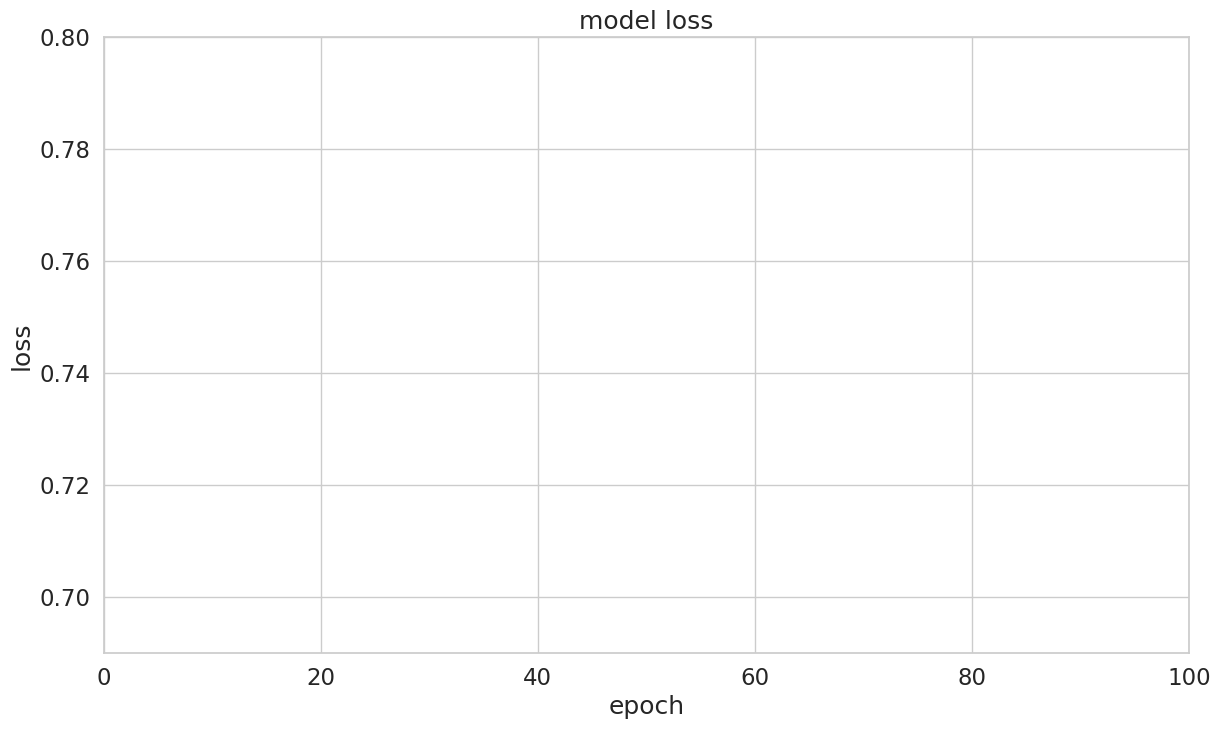

In [31]:
#history['train_loss']
#plt.plot(range(num_epochs),history['train_loss'],'ro',linewidth=2.0)
plt.plot(history['train_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.axis([0,100,0.69,0.80])
#plt.legend(['train', 'test'], loc='upper right');
plt.show()

## Оценка модели

In [34]:
pred_losses = {'pred_loss' : []}
model.eval()

# Re-initialize test_loader to ensure data is in correct tensor format
test_data_tensor = torch.from_numpy(X_test).double()
test_dataset = data_utils.TensorDataset(test_data_tensor)
test_loader = data_utils.DataLoader(test_dataset, batch_size=1, shuffle=False)

with torch.no_grad():
   # test_loss = 0
    for data_tuple in test_loader:
        inputs = data_tuple[0] # Extract the actual data tensor from the tuple
        # print(inputs)
        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()
        #print(loss)
        pred_losses['pred_loss'].append(loss)
        #pred_losses = model([y_test.size, y_test])
reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['Class'] = y_test

In [35]:
reconstructionErrorDF.describe()

,pred_loss,Class
count,25.000000,25.000000
mean,1308.745698,0.160000
std,1190.598364,0.374166
min,111.926863,0.000000
25%,352.078153,0.000000
50%,1040.858032,0.000000
75%,1815.389874,0.000000
max,4607.715774,1.000000


In [36]:
reconstructionErrorDF.describe()

,pred_loss,Class
count,25.000000,25.000000
mean,1308.745698,0.160000
std,1190.598364,0.374166
min,111.926863,0.000000
25%,352.078153,0.000000
50%,1040.858032,0.000000
75%,1815.389874,0.000000
max,4607.715774,1.000000


# Reconstruction Errors without Fraud

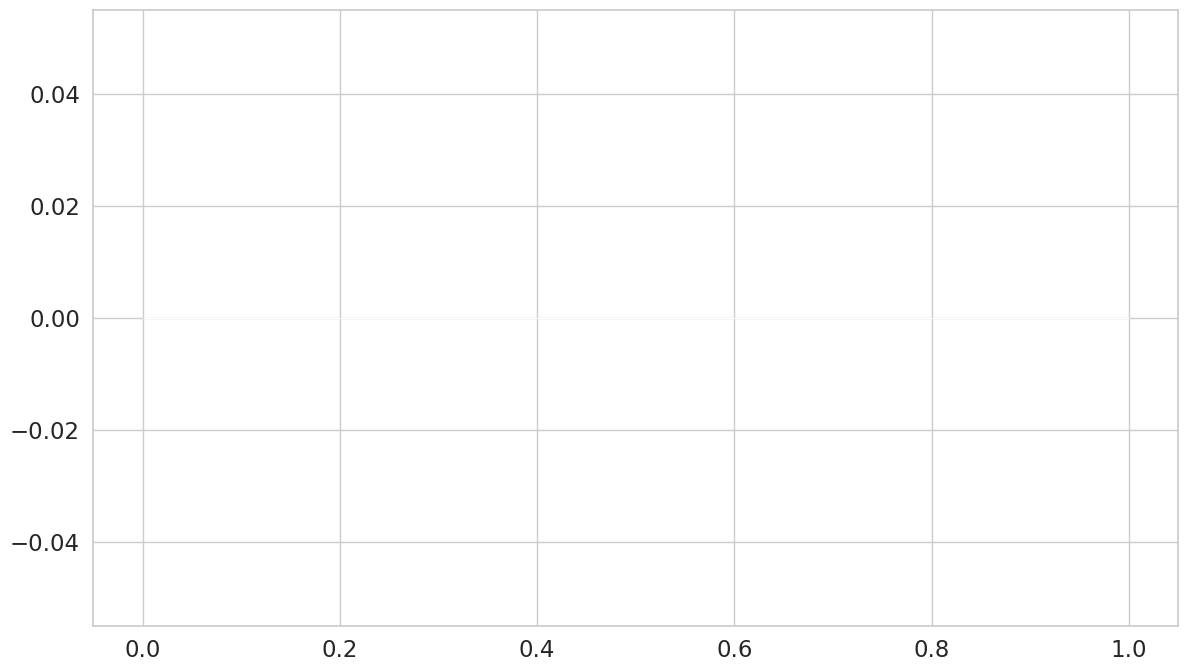

In [37]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[(reconstructionErrorDF['Class']== 0) & (reconstructionErrorDF['pred_loss'] < 10)]
_ = ax.hist(normal_error_df.pred_loss.values, bins=10)

# Reconstruction Errors with Fraud

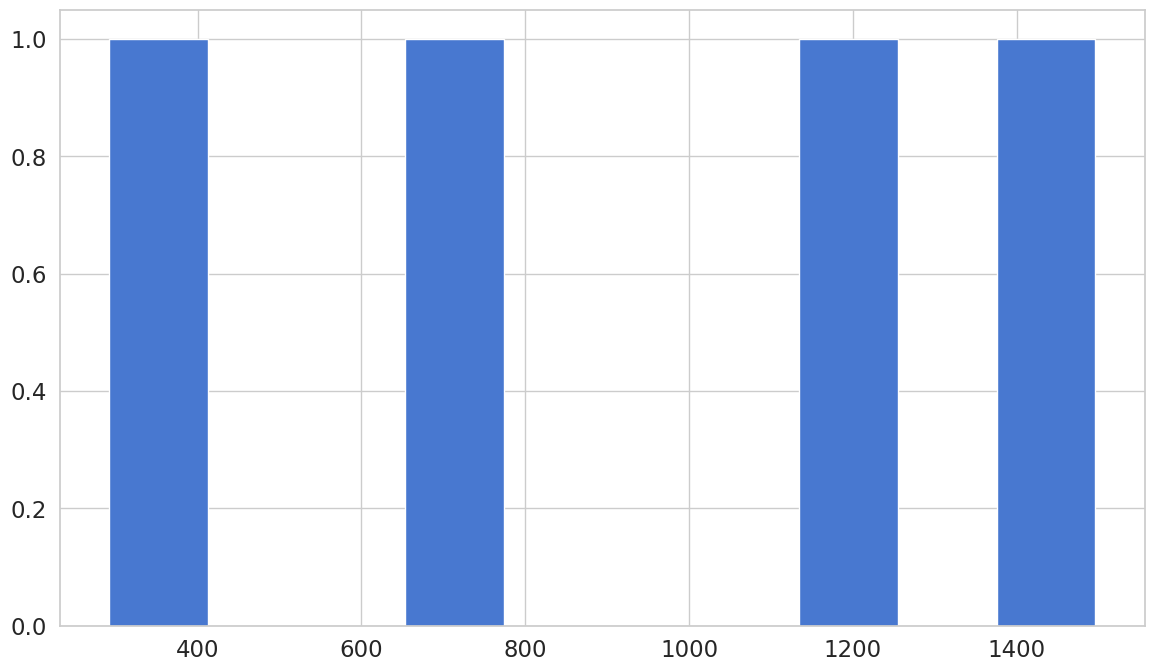

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)
fraud_error_df = reconstructionErrorDF[(reconstructionErrorDF['Class']== 1) ]
_ = ax.hist(fraud_error_df.pred_loss.values, bins=10)

## ROC Curves

ROC-кривая очень часто используется для анализа бинарных классификаторов. Он рассматривает все возможные пороговые значения для данного классификатора и показывает процент ложных срабатываний (FPR) по сравнению с показателями истинно положительных результатов (TPR).

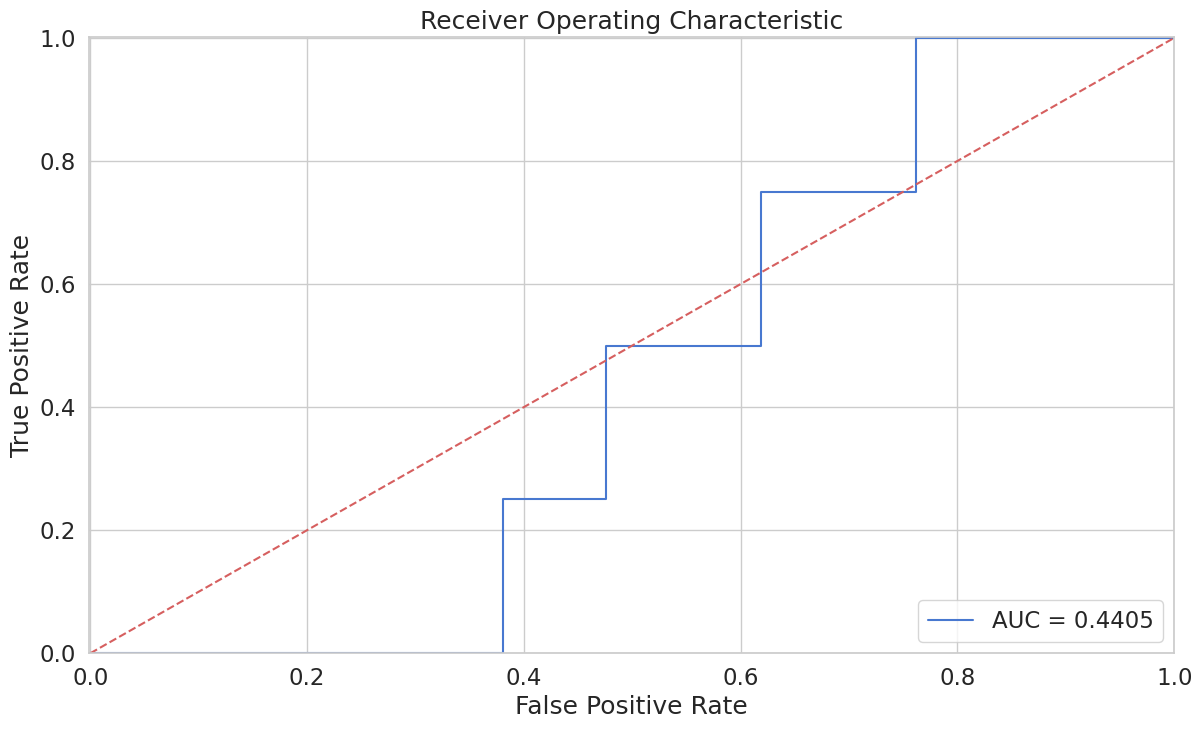

In [39]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF.Class, reconstructionErrorDF.pred_loss)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

## Precision vs Recall

Установка порога, который используется для принятия решения о классификации в модели, — это способ настроить компромисс между точностью (precision) и полнотой (recall) для данного классификатора.

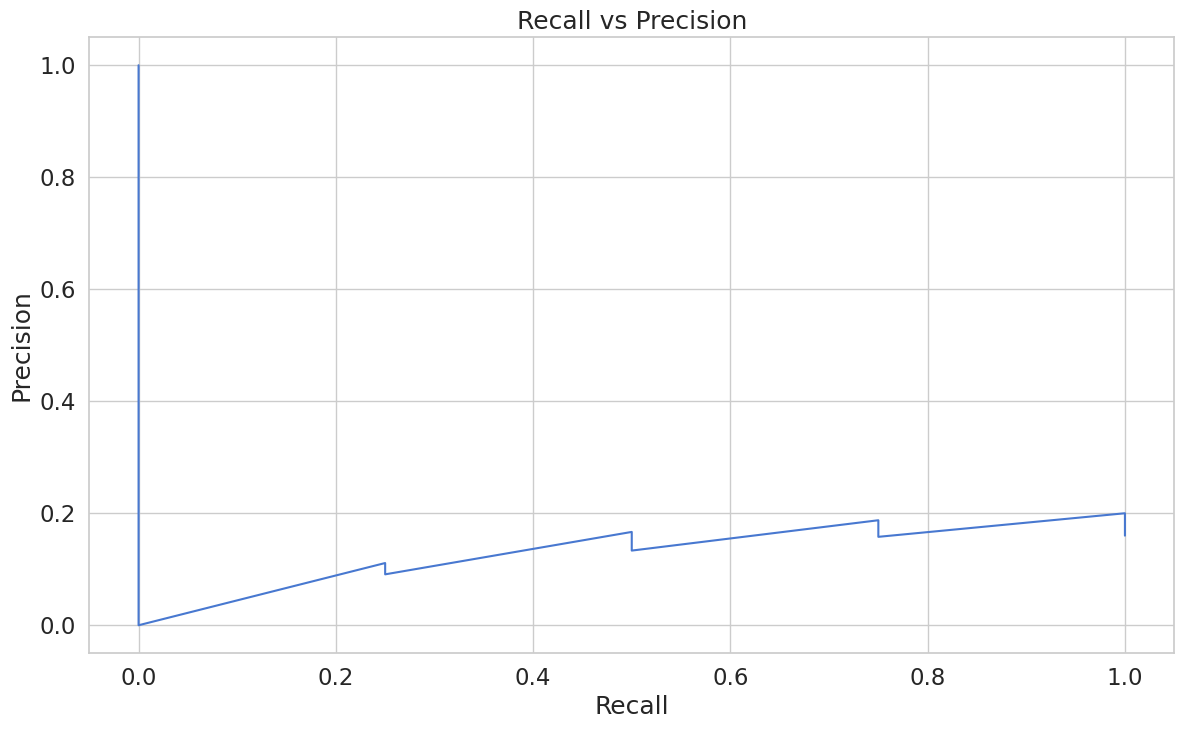

In [40]:
precision, recall, th = precision_recall_curve(reconstructionErrorDF.Class, reconstructionErrorDF.pred_loss)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

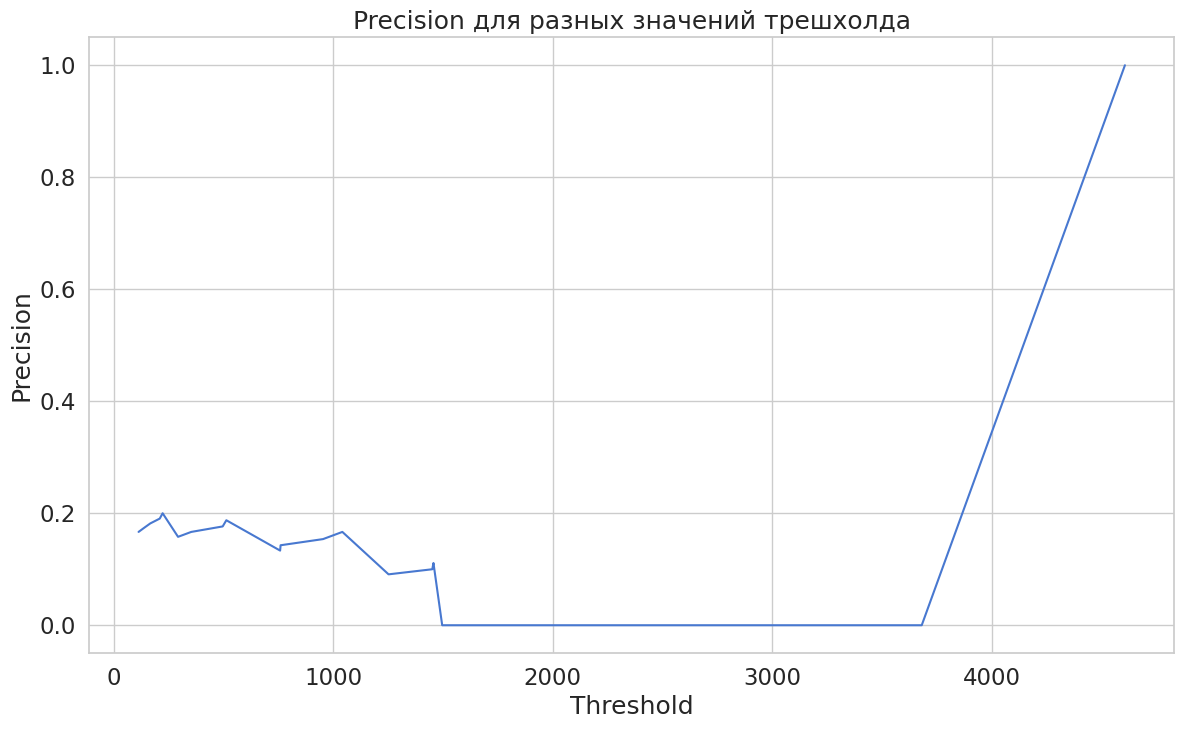

In [41]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

Вы можете видеть, что по мере увеличения ошибки реконструкции повышается и наша precision. Давайте посмотрим на recall:


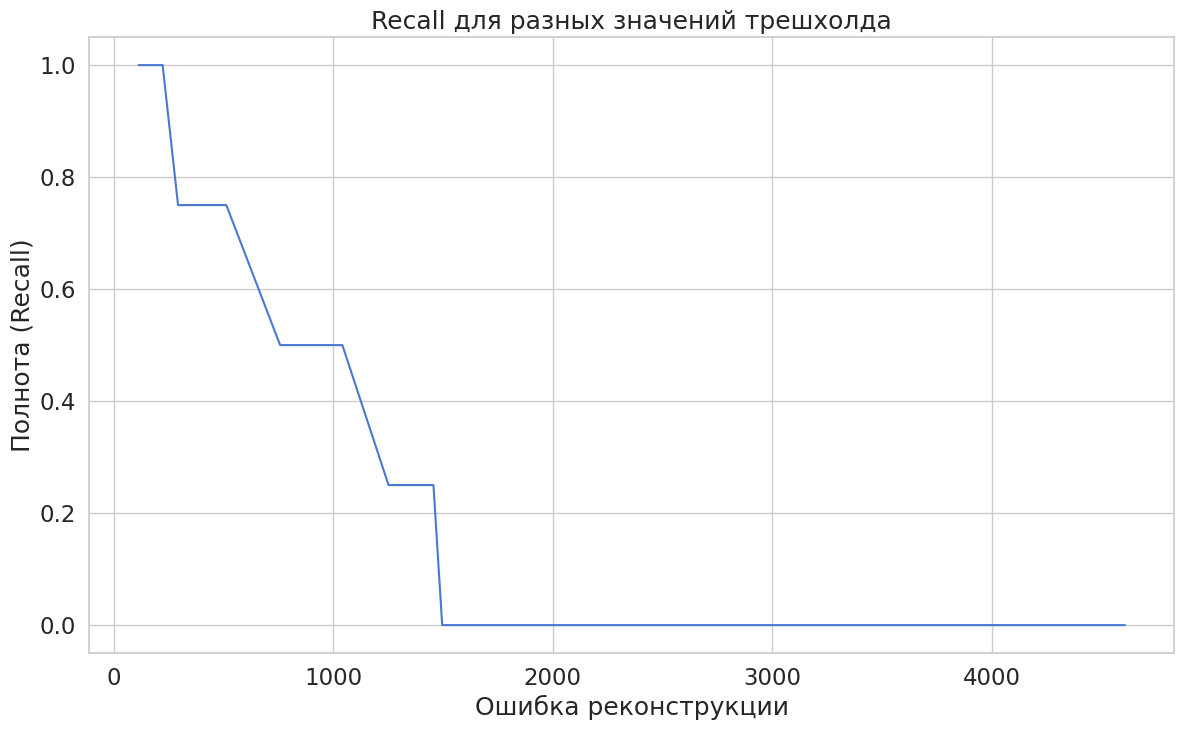

In [42]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

Здесь мы имеем прямо противоположную ситуацию. По мере увеличения ошибки реконструкции recall (полнота) уменьшается.

## Используем модель для того, чтобы сделать предсказание

Чтобы предсказать, является ли новая/невидимая транзакция нормальной или мошеннической, мы рассчитаем ошибку реконструкции на основе самих данных транзакции. Если ошибка превышает предопределенный порог, мы помечаем ее как мошенничество (поскольку наша модель должна иметь низкую ошибку при обычных транзакциях). Давайте выберем это значение:

In [43]:
threshold = 2.9

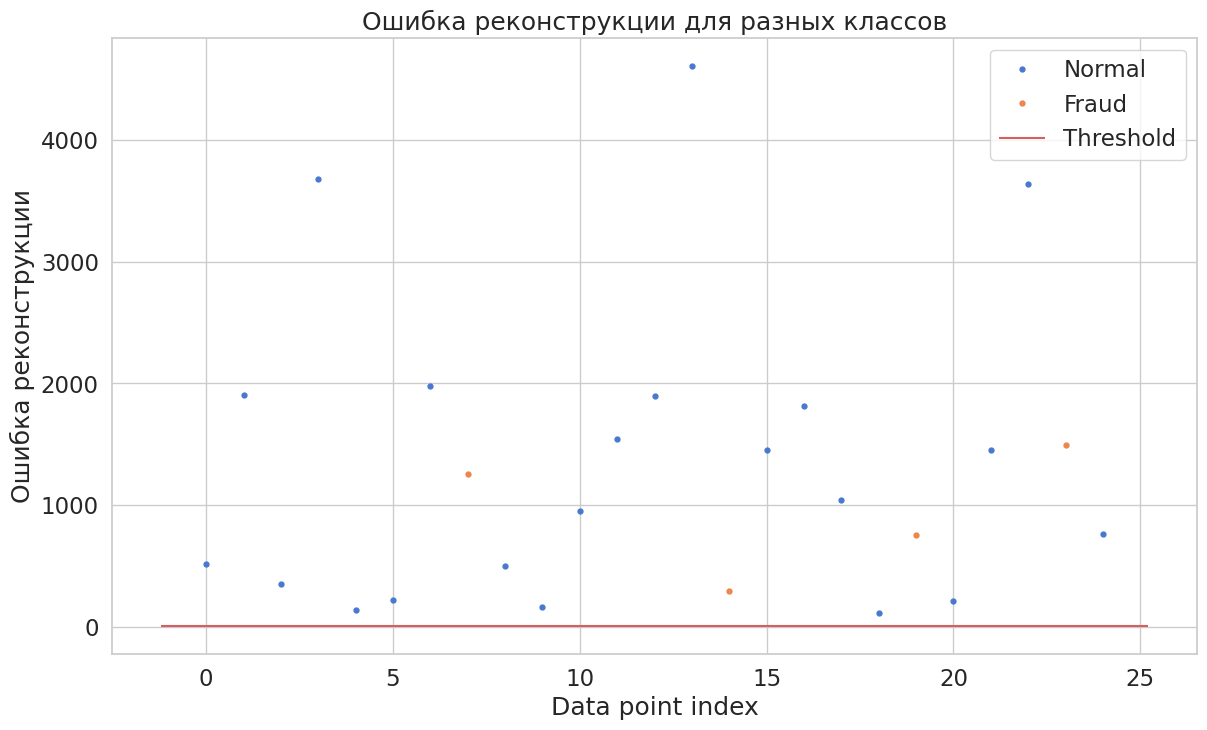

In [44]:
groups = reconstructionErrorDF.groupby('Class')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

Построим и посмотрим confusion matrix:

/tmp/ipykernel_29994/404777998.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Blues'));


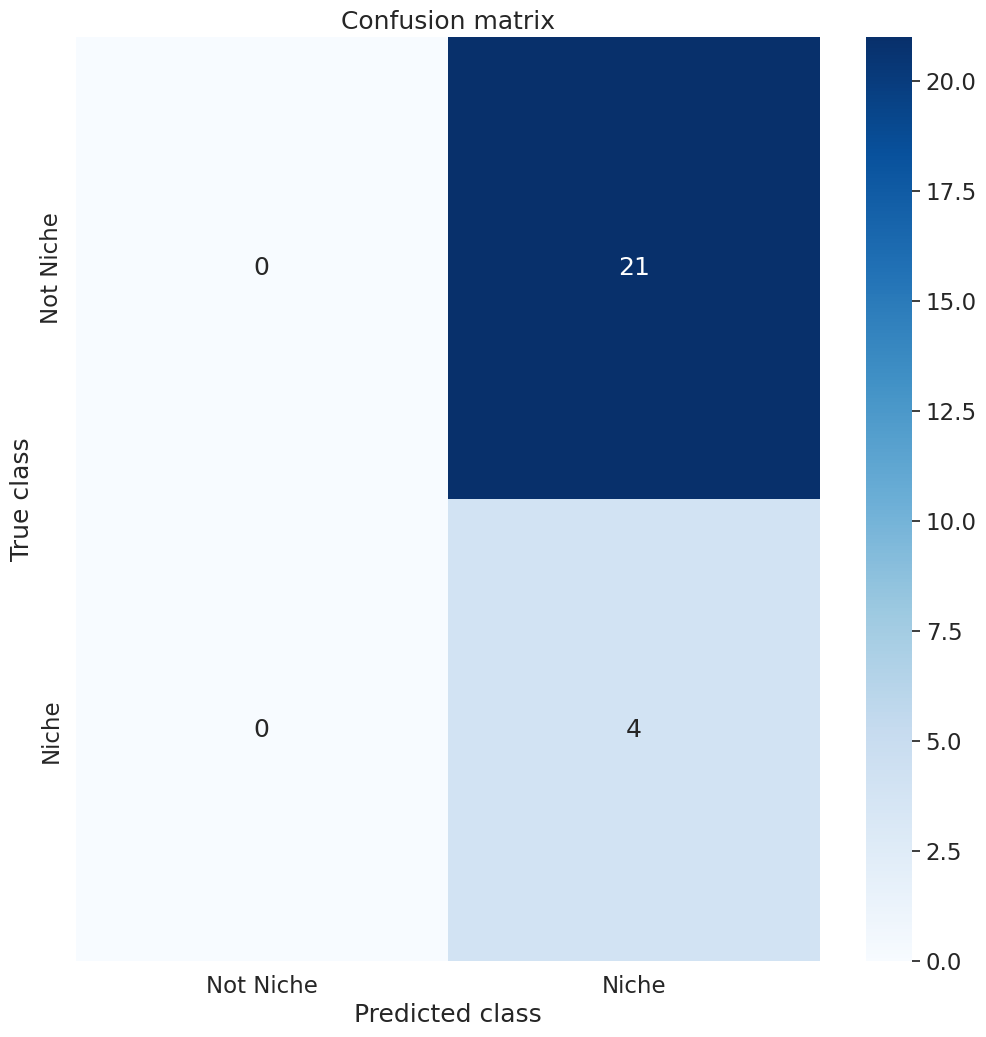

In [45]:

y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.Class, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Blues'));
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

Наша модель, похоже, выявляет множество случаев мошенничества. Но количество обычных транзакций, классифицируемых как мошенничество, действительно велико. Можно настроить порог здесь и там, чтобы получить лучшие результаты.

## Выводы


Мы создали очень простой Deep Autoencoder в PyTorch, который может реконструировать, как выглядят немошеннические транзакции. Он научился распознавать немошеннические транзакции, изучая некоторые шаблоны, присутствующие в этих транзакциях, и что это за шаблоны, о которых трудно сказать — загадка любой нейронной сети с глубоким обучением.

PyTorch предоставил нам очень понятный и простой в использовании API для создания нетривиального Deep Autoencoder. Можно попытаться создать аналогичный автоэнкодер, используя другую структуру, например Tensorflow/Keras/fast.ai, для другого домена/проблемы, например, классифицировать изображения как содержащие неприемлемый контент.